# **Laboratorio 8: Ready, Set, Deploy! 👩‍🚀👨‍🚀**

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Javier Pinochet
- Nombre de alumno 2: Daniel Muñoz

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/danmc899/MDS7202)

## Temas a tratar

- Entrenamiento y registro de modelos usando MLFlow.
- Despliegue de modelo usando FastAPI
- Containerización del proyecto usando Docker

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Generar una solución a un problema a partir de ML
- Desplegar su solución usando MLFlow, FastAPI y Docker

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# **Introducción**

<p align="center">
  <img src="https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExODJnMHJzNzlkNmQweXoyY3ltbnZ2ZDlxY2c0aW5jcHNzeDNtOXBsdCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AbPdhwsMgjMjax5reo/giphy.gif" width="400">
</p>



Consumida en la tristeza el despido de Renacín, Smapina ha decaído en su desempeño, lo que se ha traducido en un irregular tratamiento del agua. Esto ha implicado una baja en la calidad del agua, llegando a haber algunos puntos de la comuna en la que el vital elemento no es apto para el consumo humano. Es por esto que la sanitaria pública de la municipalidad de Maipú se ha contactado con ustedes para que le entreguen una urgente solución a este problema (a la vez que dejan a Smapina, al igual que Renacín, sin trabajo 😔).

El problema que la empresa le ha solicitado resolver es el de elaborar un sistema que les permita saber si el agua es potable o no. Para esto, la sanitaria les ha proveido una base de datos con la lectura de múltiples sensores IOT colocados en diversas cañerías, conductos y estanques. Estos sensores señalan nueve tipos de mediciones químicas y más una etiqueta elaborada en laboratorio que indica si el agua es potable o no el agua.

La idea final es que puedan, en el caso que el agua no sea potable, dar un aviso inmediato para corregir el problema. Tenga en cuenta que parte del equipo docente vive en Maipú y su intoxicación podría implicar graves problemas para el cierre del curso.

Atributos:

1. pH value
2. Hardness
3. Solids (Total dissolved solids - TDS)
4. Chloramines
5. Sulfate
6. Conductivity
7. Organic_carbon
8. Trihalomethanes
9. Turbidity

Variable a predecir:

10. Potability (1 si es potable, 0 no potable)

Descripción de cada atributo se pueden encontrar en el siguiente link: [dataset](https://www.kaggle.com/adityakadiwal/water-potability)

# **1. Optimización de modelos con Optuna + MLFlow (2.0 puntos)**

El objetivo de esta sección es que ustedes puedan combinar Optuna con MLFlow para poder realizar la optimización de los hiperparámetros de sus modelos.

Como aún no hemos hablado nada sobre `MLFlow` cabe preguntarse: **¡¿Qué !"#@ es `MLflow`?!**

<p align="center">
  <img src="https://media.tenor.com/eusgDKT4smQAAAAC/matthew-perry-chandler-bing.gif" width="400">
</p>

## **MLFlow**

`MLflow` es una plataforma de código abierto que simplifica la gestión y seguimiento de proyectos de aprendizaje automático. Con sus herramientas, los desarrolladores pueden organizar, rastrear y comparar experimentos, además de registrar modelos y controlar versiones.

<p align="center">
  <img src="https://spark.apache.org/images/mlflow-logo.png" width="350">
</p>

Si bien esta plataforma cuenta con un gran número de herramientas y funcionalidades, en este laboratorio trabajaremos con dos:
1. **Runs**: Registro que constituye la información guardada tras la ejecución de un entrenamiento. Cada `run` tiene su propio run_id, el cual sirve como identificador para el entrenamiento en sí mismo. Dentro de cada `run` podremos acceder a información como los hiperparámetros utilizados, las métricas obtenidas, las librerías requeridas y hasta nos permite descargar el modelo entrenado.
2. **Experiments**: Se utilizan para agrupar y organizar diferentes ejecuciones de modelos (`runs`). En ese sentido, un experimento puede agrupar 1 o más `runs`. De esta manera, es posible también registrar métricas, parámetros y archivos (artefactos) asociados a cada experimento.

### **Todo bien pero entonces, ¿cómo se usa en la práctica `MLflow`?**

Es sencillo! Considerando un problema de machine learning genérico, podemos registrar la información relevante del entrenamiento ejecutando `mlflow.autolog()` antes entrenar nuestro modelo. Veamos este bonito ejemplo facilitado por los mismos creadores de `MLflow`:

```python
#!pip install mlflow
import mlflow # importar mlflow

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor

db = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(db.data, db.target)

# Create and train models.
rf = RandomForestRegressor(n_estimators=100, max_depth=6, max_features=3)

mlflow.autolog() # registrar automáticamente información del entrenamiento
with mlflow.start_run(): # delimita inicio y fin del run
    # aquí comienza el run
    rf.fit(X_train, y_train) # train the model
    predictions = rf.predict(X_test) # Use the model to make predictions on the test dataset.
    # aquí termina el run
```

Si ustedes ejecutan el código anterior en sus máquinas locales (desde un jupyter notebook por ejemplo) se darán cuenta que en su directorio *root* se ha creado la carpeta `mlruns`. Esta carpeta lleva el tracking de todos los entrenamientos ejecutados desde el directorio root (importante: si se cambian de directorio y vuelven a ejecutar el código anterior, se creará otra carpeta y no tendrán acceso al entrenamiento anterior). Para visualizar estos entrenamientos, `MLflow` nos facilita hermosa interfaz visual a la que podemos acceder ejecutando:

```
mlflow ui
```

y luego pinchando en la ruta http://127.0.0.1:5000 que nos retorna la terminal. Veamos en vivo algunas de sus funcionalidades!

<p align="center">
  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExZXVuM3A5MW1heDFpa21qbGlwN2pyc2VoNnZsMmRzODZxdnluemo2bCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/3o84sq21TxDH6PyYms/giphy.gif" width="400">
</p>

Les dejamos también algunos comandos útiles:

- `mlflow.create_experiment("nombre_experimento")`: Les permite crear un nuevo experimento para agrupar entrenamientos
- `mlflow.log_metric("nombre_métrica", métrica)`: Les permite registrar una métrica *custom* bajo el nombre de "nombre_métrica"


## **1.1 Combinando Optuna + MLflow (2.0 puntos)**

Ahora que tenemos conocimiento de ambas herramientas, intentemos ahora combinarlas para **más sabor**. El objetivo de este apartado es simple: automatizar la optimización de los parámetros de nuestros modelos usando `Optuna` y registrando de forma automática cada resultado en `MLFlow`.

Considerando el objetivo planteado, se le pide completar la función `optimize_model`, la cual debe:
- **Optimizar los hiperparámetros del modelo `XGBoost` usando `Optuna`.**
- **Registrar cada entrenamiento en un experimento nuevo**, asegurándose de que la métrica `f1-score` se registre como `"valid_f1"`. No se deben guardar todos los experimentos en *Default*; en su lugar, cada `experiment` y `run` deben tener nombres interpretables, reconocibles y diferentes a los nombres por defecto (por ejemplo, para un run: "XGBoost con lr 0.1").
- **Guardar los gráficos de Optuna** dentro de una carpeta de artefactos de Mlflow llamada `/plots`.
- **Devolver el mejor modelo** usando la función `get_best_model` y serializarlo en el disco con `pickle.dump`. Luego, guardar el modelo en la carpeta `/models`.
- **Guardar el código en `optimize.py`**. La ejecución de `python optimize.py` debería ejecutar la función `optimize_model`.
- **Guardar las versiones de las librerías utilizadas** en el desarrollo.
- **Respalde las configuraciones del modelo final y la importancia de las variables** en un gráfico dentro de la carpeta `/plots` creada anteriormente.

*Hint: Le puede ser útil revisar los parámetros que recibe `mlflow.start_run`*

```python
def get_best_model(experiment_id):
    runs = mlflow.search_runs(experiment_id)
    best_model_id = runs.sort_values("metrics.valid_f1")["run_id"].iloc[0]
    best_model = mlflow.sklearn.load_model("runs:/" + best_model_id + "/model")

    return best_model
```

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\javpi\mds7202\Lab8\water_potability.csv")
df.head()

In [ ]:
# Número de NaN por columna
na_count = df.isna().sum()
print(na_count)

In [ ]:
# Número de duplicados por columna
dup_count = df.duplicated().sum()
print(dup_count)

In [ ]:
df.describe()

In [ ]:
df.info()

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import mlflow
import mlflow.sklearn
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
#%pip install -U kaleido
#%pip install --upgrade plotly

# Configuración
RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)


def get_best_model(experiment_id):
    """Obtiene el mejor modelo basado en valid_f1"""
    runs = mlflow.search_runs(experiment_id)
    best_model_id = runs.sort_values("metrics.valid_f1", ascending=False)["run_id"].iloc[0]
    best_model = mlflow.sklearn.load_model("runs:/" + best_model_id + "/model")
    return best_model

def optimize_model():
    """Función principal para optimizar el modelo con Optuna y registrar con MLflow"""
    
    # Cargar datos
    df = pd.read_csv(r"C:\Users\dlamu\Downloads\Lab8\water_potability.csv")
    df["Potability"] = df["Potability"].astype(float)
    
    # Aplicar IQR y clipear outliers
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    num_cols.remove("Potability")
    lam = 1.5
    Q1 = df[num_cols].quantile(0.25)
    Q3 = df[num_cols].quantile(0.75)
    IQR_val = Q3 - Q1
    lower_bound = Q1 - lam * IQR_val
    upper_bound = Q3 + lam * IQR_val
    
    # Aplicar clip
    df[num_cols] = df[num_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)
    
    # Separar variables
    X = df.drop(columns=["Potability"])
    y = df["Potability"]
    
    # Split de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE
    )
    
    # Preprocesamiento
    preprocessor = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", MinMaxScaler())
    ])
    
    # Crear o recuperar experimento en MLflow
    experiment_name = "Water_Potability_XGBoost_Optimization"
    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        experiment_id = mlflow.create_experiment(experiment_name)
    else:
        experiment_id = experiment.experiment_id
    
    # Función objetivo para Optuna
    def objective(trial):
        # Hiperparámetros sugeridos por Optuna
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
            "random_state": RANDOM_STATE,
            "eval_metric": "logloss"
        }
        
        # Crear pipeline
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(**params))
        ])
        
        # Nombre del run con información relevante
        run_name = f"XGBoost_lr_{params['learning_rate']:.4f}_depth_{params['max_depth']}"
        
        # Iniciar run de MLflow
        with mlflow.start_run(experiment_id=experiment_id, run_name=run_name):
            # Registrar parámetros
            mlflow.log_params(params)
            
            # Entrenar modelo
            pipeline.fit(X_train, y_train)
            
            # Predecir
            y_pred = pipeline.predict(X_test)
            
            # Calcular f1-score
            f1 = f1_score(y_test, y_pred)
            
            # Registrar métrica como valid_f1
            mlflow.log_metric("valid_f1", f1)
            
            # Guardar modelo
            mlflow.sklearn.log_model(pipeline, "model", input_example=X_train.iloc[0:1])
            
        return f1
    
    # Configurar y ejecutar estudio de Optuna
    sampler = TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, timeout=60, show_progress_bar=True)
    
    # Imprimir resultados
    print(f"Número de trials completados: {len(study.trials)}")
    print(f"Mejor f1-score (test): {study.best_value}")
    print("Mejores hiperparámetros encontrados:")
    for key, value in study.best_params.items():
        print(f"  - {key}: {value}")
    
    # Crear carpetas si no existen
    os.makedirs("plots", exist_ok=True)
    os.makedirs("models", exist_ok=True)
    
    # Guardar gráficos de Optuna
    fig1 = plot_optimization_history(study)
    fig1.write_image("plots/optimization_history.png")
    
    fig2 = plot_param_importances(study)
    fig2.write_image("plots/param_importances.png")
    
    # Registrar gráficos en MLflow
    with mlflow.start_run(experiment_id=experiment_id, run_name="Best_Model_Artifacts"):
        mlflow.log_artifact("plots/optimization_history.png", artifact_path="plots")
        mlflow.log_artifact("plots/param_importances.png", artifact_path="plots")
    
    # Obtener el mejor modelo
    best_model = get_best_model(experiment_id)
    
    # Serializar el mejor modelo con pickle
    with open("models/best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)
    
    print("\nModelo guardado en: models/best_model.pkl")
    
    # Guardar importancia de features del mejor modelo
    if hasattr(best_model.named_steps['model'], 'feature_importances_'):
        feature_importance = best_model.named_steps['model'].feature_importances_
        features = X.columns
        
        plt.figure(figsize=(10, 6))
        plt.barh(features, feature_importance)
        plt.xlabel('Importancia')
        plt.ylabel('Features')
        plt.title('Importancia de Variables - Mejor Modelo XGBoost')
        plt.tight_layout()
        plt.savefig("plots/feature_importance.png")
        plt.close()
        
        print("Gráfico de importancia guardado en: plots/feature_importance.png")
    
    # Guardar versiones de librerías
    with open("requirements.txt", "w") as f:
        f.write(f"pandas=={pd.__version__}\n")
        f.write(f"numpy=={np.__version__}\n")
        f.write(f"scikit-learn==1.7.2\n")
        f.write(f"xgboost==2.0.0\n")
        f.write(f"optuna==3.4.0\n")
        f.write(f"mlflow==3.5.0\n")
        f.write(f"matplotlib==3.8.0\n")
        f.write(f"plotly==5.17.0\n")
        f.write(f"kaleido==0.2.1\n")
    
    print("Requisitos guardados en: requirements.txt")
    
    return best_model

if __name__ == "__main__":
    optimize_model()

   0%|          | 00:00/01:00

2025/10/20 22:22:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\javpi\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2025/10/20 22:23:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\javpi\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2025/10/20 22:23:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\javpi\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2025/10/20 22:23:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\javpi\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

2025/10/20 22:23:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\javpi\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2025/10/20 22:23:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\javpi\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2025/10/20 22:23:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\javpi\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Número de trials completados: 15
Mejor f1-score (test): 0.4823348694316436
Mejores hiperparámetros encontrados:
  - learning_rate: 0.29326060138888105
  - n_estimators: 343
  - max_depth: 5
  - min_child_weight: 4
  - gamma: 2.855546834345709
  - subsample: 0.6822496788829664
  - colsample_bytree: 0.62077746649017
  - reg_alpha: 0.00011628971093360688
  - reg_lambda: 1.3178360309852975e-05



Modelo guardado en: models/best_model.pkl
Gráfico de importancia guardado en: plots/feature_importance.png
Requisitos guardados en: requirements.txt


# **2. FastAPI (2.0 puntos)**

<div align="center">
  <img src="https://media3.giphy.com/media/YQitE4YNQNahy/giphy-downsized-large.gif" width="500">
</div>

Con el modelo ya entrenado, la idea de esta sección es generar una API REST a la cual se le pueda hacer *requests* para así interactuar con su modelo. En particular, se le pide:

- Guardar el código de esta sección en el archivo `main.py`. Note que ejecutar `python main.py` debería levantar el servidor en el puerto por defecto.
- Defina `GET` con ruta tipo *home* que describa brevemente su modelo, el problema que intenta resolver, su entrada y salida.
- Defina un `POST` a la ruta `/potabilidad/` donde utilice su mejor optimizado para predecir si una medición de agua es o no potable. Por ejemplo, una llamada de esta ruta con un *body*:

```json
{
   "ph":10.316400384553162,
   "Hardness":217.2668424334475,
   "Solids":10676.508475429378,
   "Chloramines":3.445514571005745,
   "Sulfate":397.7549459751925,
   "Conductivity":492.20647361771086,
   "Organic_carbon":12.812732207582542,
   "Trihalomethanes":72.28192021570328,
   "Turbidity":3.4073494284238364
}
```

Su servidor debería retornar una respuesta HTML con código 200 con:


```json
{
  "potabilidad": 0 # respuesta puede variar según el clasificador que entrenen
}
```

**`HINT:` Recuerde que puede utilizar [http://localhost:8000/docs](http://localhost:8000/docs) para hacer un `POST`.**

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import pickle
import pandas as pd

# -------------------------------------------------------------------
# 1. Cargar el modelo entrenado
# -------------------------------------------------------------------
with open("models/best_model.pkl", "rb") as f:
    model = pickle.load(f)

# -------------------------------------------------------------------
# 2. Crear la aplicación FastAPI
# -------------------------------------------------------------------
app = FastAPI(title="API de Predicción de Potabilidad del Agua")

# -------------------------------------------------------------------
# 3. Definir el modelo de datos de entrada
# -------------------------------------------------------------------
class WaterQuality(BaseModel):
    ph: float
    Hardness: float
    Solids: float
    Chloramines: float
    Sulfate: float
    Conductivity: float
    Organic_carbon: float
    Trihalomethanes: float
    Turbidity: float

# -------------------------------------------------------------------
# 4. Ruta principal (GET /)
# -------------------------------------------------------------------
@app.get("/")
def home():
    """
    Muestra información general de la API.
    Se accede escribiendo http://127.0.0.1:8000/ en el navegador.
    """
    return {
        "mensaje": "API de Predicción de Potabilidad del Agua",
        "descripcion": "Este modelo utiliza XGBoost optimizado con Optuna para predecir si una muestra de agua es potable o no.",
        "problema": "Clasificación binaria basada en 9 mediciones químicas.",
        "entrada": {
            "ph": "Nivel de pH del agua",
            "Hardness": "Dureza del agua",
            "Solids": "Sólidos totales disueltos",
            "Chloramines": "Nivel de cloraminas",
            "Sulfate": "Nivel de sulfatos",
            "Conductivity": "Conductividad eléctrica",
            "Organic_carbon": "Carbono orgánico",
            "Trihalomethanes": "Nivel de trihalometanos",
            "Turbidity": "Turbidez"
        },
        "salida": {
            "potabilidad": "0 (no potable) o 1 (potable)"
        }
    }

# -------------------------------------------------------------------
# 5. Ruta de predicción (POST /potabilidad/)
# -------------------------------------------------------------------
@app.post("/potabilidad/")
def predict_potability(data: WaterQuality):
    """
    Recibe los valores químicos del agua y devuelve si es potable o no.
    Se prueba desde http://127.0.0.1:8000/docs
    """
    # Convertir los datos de entrada a DataFrame
    input_data = pd.DataFrame([data.model_dump()])

    # Realizar predicción
    prediction = int(model.predict(input_data)[0])

    # Probabilidad de la predicción
    try:
        probability = float(model.predict_proba(input_data)[0][prediction])
    except Exception:
        probability = None

    # Retornar resultado
    return {
        "prediccion": prediction,
        "probabilidad": round(probability, 4) if probability else None,
        "interpretacion": "Potable" if prediction == 1 else "No potable"
    }


In [1]:
import pickle
import pandas as pd

# Carga el modelo
with open("models/best_model.pkl", "rb") as f:
    model = pickle.load(f)

# Crea un ejemplo con las mismas columnas que espera la API
ejemplo = pd.DataFrame([{
    "ph": 7.0,
    "Hardness": 180.0,
    "Solids": 20000.0,
    "Chloramines": 7.0,
    "Sulfate": 300.0,
    "Conductivity": 400.0,
    "Organic_carbon": 15.0,
    "Trihalomethanes": 60.0,
    "Turbidity": 3.0
}])

# Predice
pred = model.predict(ejemplo)
print("Predicción:", pred)


Predicción: [0]


In [5]:
# pip install scikit-learn==1.7.2



  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


  You can safely remove it manually.


# **3. Docker (2 puntos)**

<div align="center">
  <img src="https://miro.medium.com/v2/resize:fit:1400/1*9rafh2W0rbRJIKJzqYc8yA.gif" width="500">
</div>

Tras el éxito de su aplicación web para generar la salida, Smapina le solicita que genere un contenedor para poder ejecutarla en cualquier computador de la empresa de agua potable.

## **3.1 Creación de Container (1 punto)**

Cree un Dockerfile que use una imagen base de Python, copie los archivos del proyecto e instale las dependencias desde un `requirements.txt`. Con esto, construya y ejecute el contenedor Docker para la API configurada anteriormente. Entregue el código fuente (incluyendo `main.py`, `requirements.txt`, y `Dockerfile`) y la imagen Docker de la aplicación. Para la dockerización, asegúrese de cumplir con los siguientes puntos:

1. **Generar un archivo `.dockerignore`** que ignore carpetas y archivos innecesarios dentro del contenedor.
2. **Configurar un volumen** que permita la persistencia de los datos en una ruta local del computador.
3. **Exponer el puerto** para acceder a la ruta de la API sin tener que entrar al contenedor directamente.
4. **Incluir imágenes en el notebook** que muestren la ejecución del contenedor y los resultados obtenidos.
5. **Revisar y comentar los recursos utilizados por el contenedor**. Analice si los contenedores son livianos en términos de recursos.

## **3.2 Preguntas de Smapina (1 punto)**
Tras haber experimentado con Docker, Smapina desea profundizar más en el tema y decide realizarle las siguientes consultas:

- ¿Cómo se diferencia Docker de una máquina virtual (VM)?
- ¿Cuál es la diferencia entre usar Docker y ejecutar la aplicación directamente en el sistema local?
- ¿Cómo asegura Docker la consistencia entre diferentes entornos de desarrollo y producción?
- ¿Cómo se gestionan los volúmenes en Docker para la persistencia de datos?
- ¿Qué son Dockerfile y docker-compose.yml, y cuál es su propósito?

In [ ]:
#Dockerfile
# 1️⃣ Imagen base oficial de Python
FROM python:3.10-slim

# 2️⃣ Directorio de trabajo dentro del contenedor
WORKDIR /app

# 3️⃣ Copiar e instalar dependencias
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# 4️⃣ Copiar todos los archivos del proyecto (incluye main.py y models/)
COPY . .

# 5️⃣ Exponer el puerto 8000 (PUNTO 3)
EXPOSE 8000

# 6️⃣ Comando para ejecutar la API
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]


In [ ]:
#.dockerignore
__pycache__/
*.ipynb
*.csv
*.xlsx
*.log
*.png
*.jpg
*.jpeg
*.gif
*.pdf
*.zip
*.tar
*.gz
*.pkl
*.db
.DS_Store
.env
.vscode/
.idea/
tests/
notebooks/
mlruns/
plots/

In [ ]:
#Configración de volúmenes
#Se monta la carpeta C:\Users\dlamu\Downloads\Lab8\models en la ruta  dentro del contenedor /app/models potabilidad-api
docker run -d -p 8000:8000 -v C:\Users\dlamu\Downloads\Lab8\models:/app/models potabilidad-api

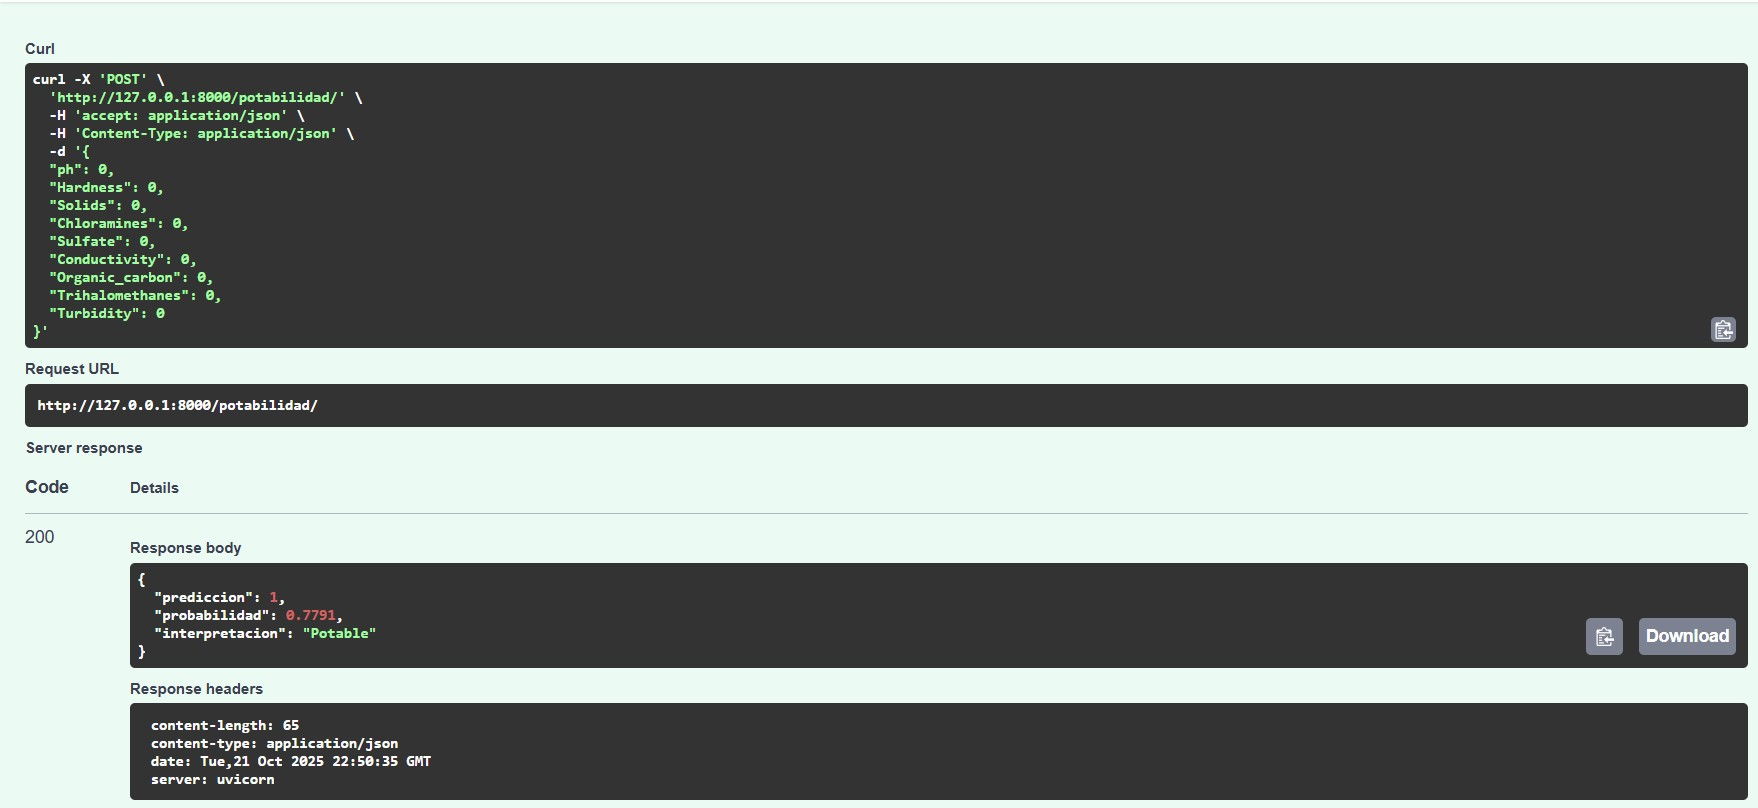

In [6]:
# Imágenes de ejecución del contenedor
from IPython.display import Image
Image("test1docker.jpg")

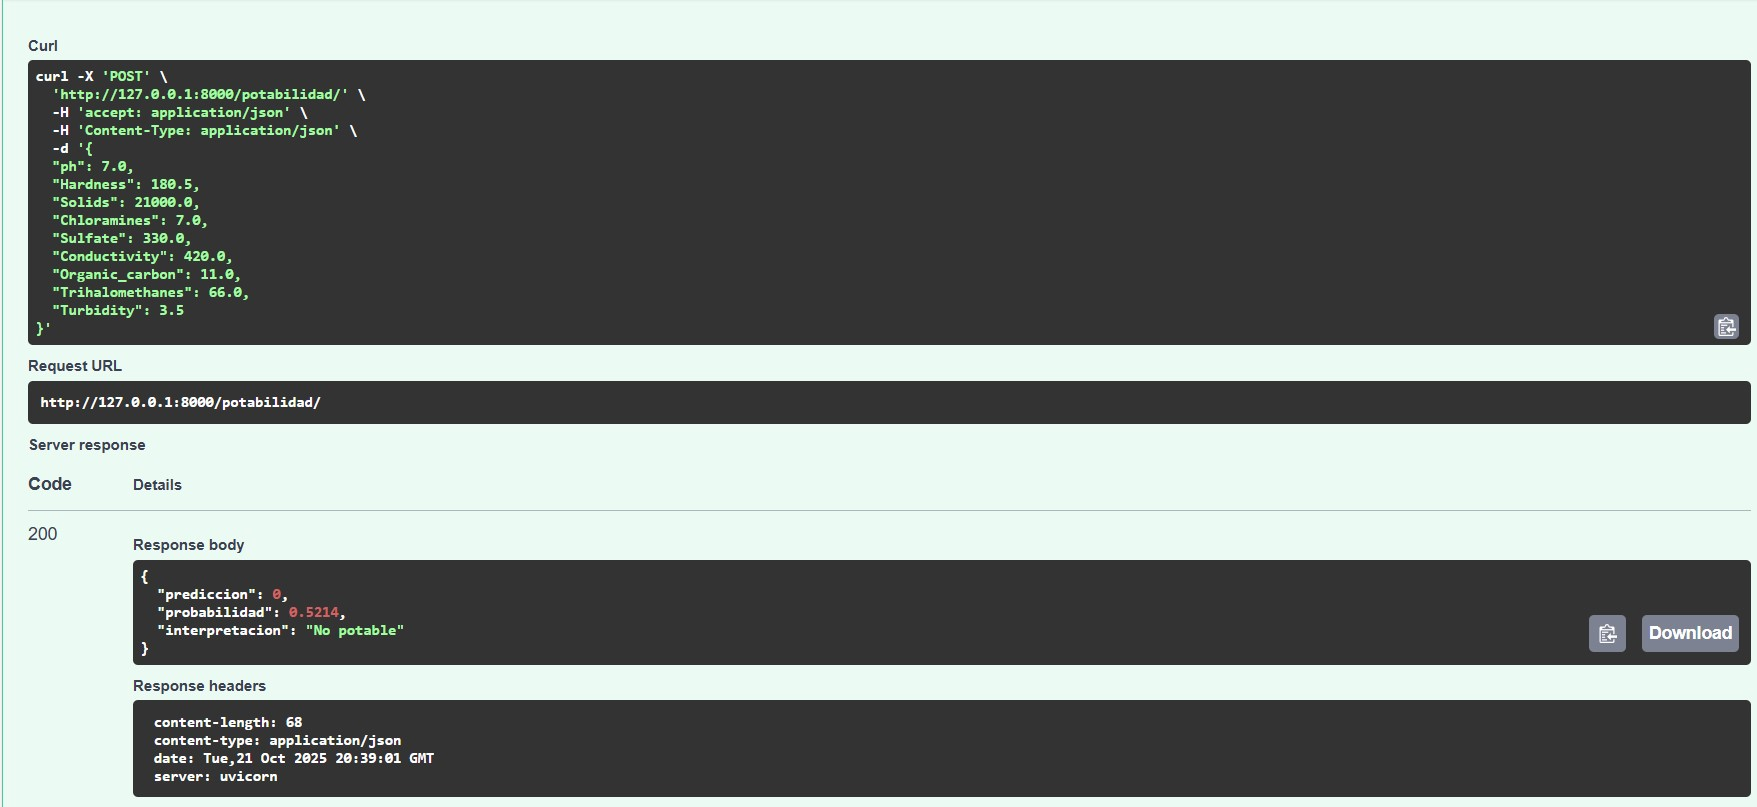

In [7]:
Image("test2docker.jpg")

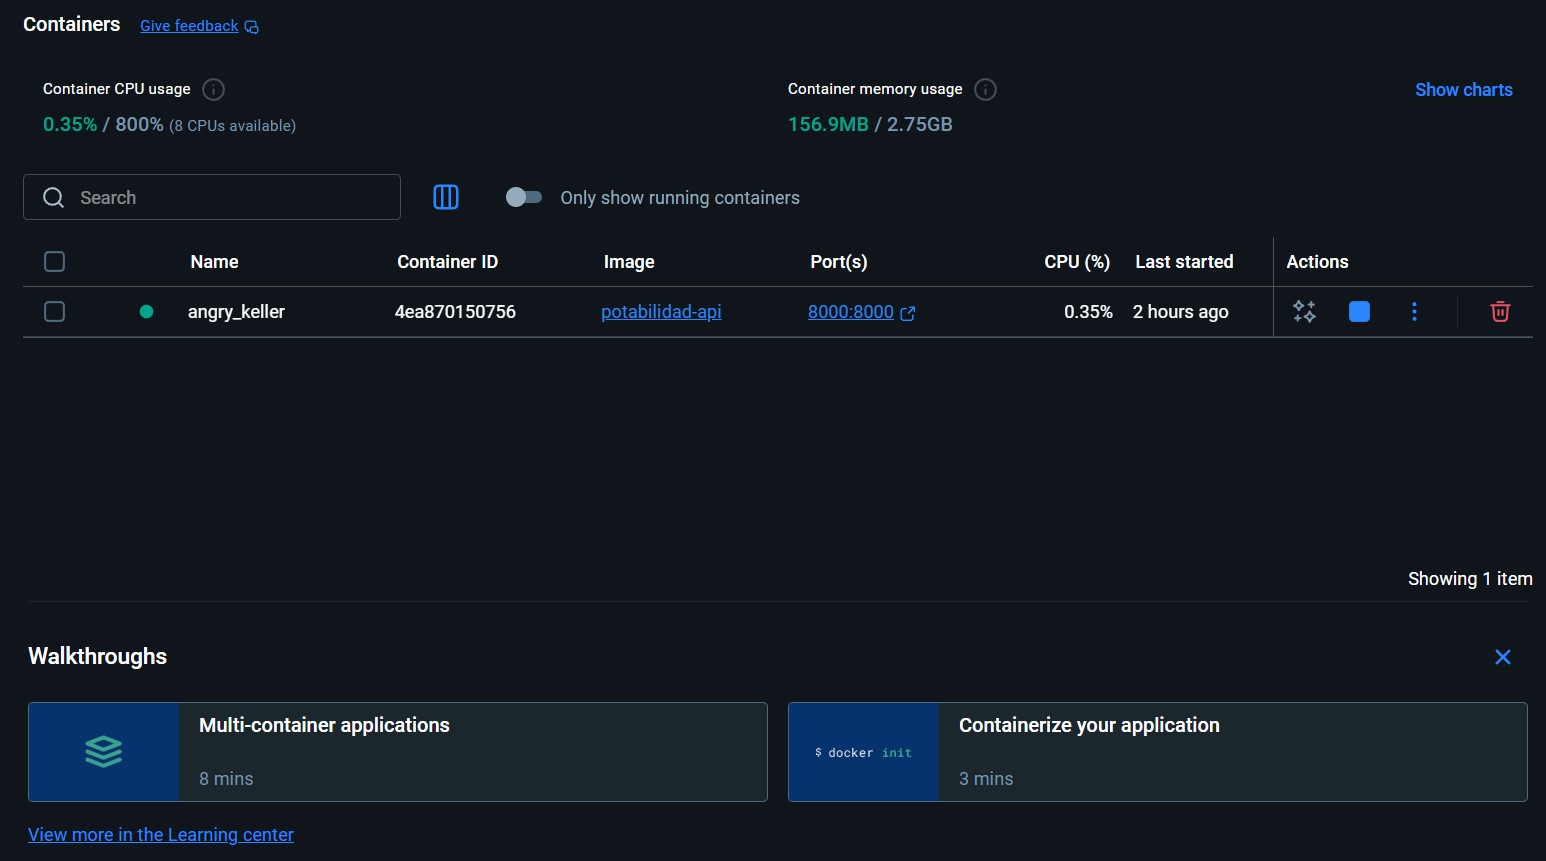

In [9]:
Image("containerfuncionando.jpg")

In [ ]:
#Recursos
CONTAINER ID   NAME           CPU %     MEM USAGE / LIMIT     MEM %     NET I/O           BLOCK I/O       PIDS
4ea870150756   angry_keller   0.25%     156.9MiB / 2.813GiB   5.45%     6.44kB / 6.02kB   100MB / 434kB   31

El consumo de CPU es muy bajo, sin carga significcativa, también hay mucha memoria disponible, el tráfico de red es estable, también ha hecho mucha escritura pero poca lectura y por último, su número de procesos es razonable.


**3.2 Preguntas de Smapina (1 punto)**
Tras haber experimentado con Docker, Smapina desea profundizar más en el tema y decide realizarle las siguientes consultas:

- ¿Cómo se diferencia Docker de una máquina virtual (VM)?

- Docker utiliza el sistema operativo y comparte sus recursos, en cambio, las máquinas virtuales requieren una copia completa del sistema operativo. También Docker es gestionado por un motor de contenedores y se construyen con imágenes ligeras y archivos de configuración, mientras que las máquinas virtuales necesitan hipervisores para gestionarse. Por último las máquinas virtuales tardan mucho más en inicializarse que Docker

- ¿Cuál es la diferencia entre usar Docker y ejecutar la aplicación directamente en el sistema local?

- Ejecutarlo en Docker es útil para contextos de producción, donde se espera que varios clientes estén conectados a un mismo modelo o servicio de nube. Por lo mismo para trabajar con Docker hay restricciones de datos sensibles, autenticación y mayor seguridad. Además de haber una optimización de tecutsos para manejar grandes volumenes con alta disponibilidad.

- ¿Cómo asegura Docker la consistencia entre diferentes entornos de desarrollo y producción?

- Se asegura con un archivo requirements.txt que garantiza la reproducibilidad imponiendo librerías a utilizar por los modelos, además sistemas operativos, hardware y código fuente.

- ¿Cómo se gestionan los volúmenes en Docker para la persistencia de datos?

- En Docker, los volúmenes permiten persistir datos fuera del contenedor, de modo que no se pierden al detener o eliminar el contenedor. Se pueden gestionar creando un volumen y montándolo en contenedores, pudiendo compartirse entre contenedores y respaldarse fácilmente, mientras Docker optimiza su rendimiento y compatibilidad entre plataformas.

- ¿Qué son Dockerfile y docker-compose.yml, y cuál es su propósito?

- Dockerfile es un archivo de texto que definelas instrucciones necesarias para construir una imagen de Docker; esto es el sistema base, dependencias, archivos a copiar y comandos a ejecutar, generando un contenedor listo para usar; su proposito es automatizar la creación de imágenes. Mientras que docker-compose.yml es un archivo YAML que puede definir y ejecutar múltiples contenedores en un solo servicio con redes, volúmenes y dependencias entre ellos; su propósito es coordinar muchos entornos de ejecución completos.

# Conclusión

Éxito!
<div align="center">
  <img src="https://i.pinimg.com/originals/55/f5/fd/55f5fdc9455989f8caf7fca7f93bd96a.gif" width="500">
</div>